
# Knowing the data



In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,FunctionTransformer,PowerTransformer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:

data = pd.read_csv('electricity_bill_dataset.csv')
data.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


In [ ]:
data.shape

(45345, 12)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int64  
 1   Refrigerator     45345 non-null  float64
 2   AirConditioner   45345 non-null  float64
 3   Television       45345 non-null  float64
 4   Monitor          45345 non-null  float64
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  object 
 8   Company          45345 non-null  object 
 9   MonthlyHours     45345 non-null  int64  
 10  TariffRate       45345 non-null  float64
 11  ElectricityBill  45345 non-null  float64
dtypes: float64(6), int64(4), object(2)
memory usage: 4.2+ MB


In [ ]:
data.columns

Index(['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor',
       'MotorPump', 'Month', 'City', 'Company', 'MonthlyHours', 'TariffRate',
       'ElectricityBill'],
      dtype='object')

# Type casting

In [ ]:
typecast=['Fan', 'Refrigerator', 'AirConditioner', 'Television','Monitor']

In [ ]:
for i in typecast:
  data[i] = data[i].astype('int32')

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int32  
 1   Refrigerator     45345 non-null  int32  
 2   AirConditioner   45345 non-null  int32  
 3   Television       45345 non-null  int32  
 4   Monitor          45345 non-null  int32  
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  object 
 8   Company          45345 non-null  object 
 9   MonthlyHours     45345 non-null  int64  
 10  TariffRate       45345 non-null  float64
 11  ElectricityBill  45345 non-null  float64
dtypes: float64(2), int32(5), int64(3), object(2)
memory usage: 3.3+ MB


In [ ]:
data.isnull().sum()

,0
Fan,0
Refrigerator,0
AirConditioner,0
Television,0
Monitor,0
MotorPump,0
Month,0
City,0
Company,0
MonthlyHours,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,TariffRate,ElectricityBill
count,45345.000000,45345.000000,45345.000000,45345.000000,45345.000000,45345.0,45345.000000,45345.000000,45345.000000,45345.000000
mean,13.990694,21.705458,1.503959,12.502635,2.865057,0.0,6.488058,515.083207,8.369648,4311.771307
std,5.470816,1.672575,1.115482,5.756007,3.894933,0.0,3.443252,122.618017,0.576992,1073.886406
min,5.000000,17.000000,0.000000,3.000000,1.000000,0.0,1.000000,95.000000,7.400000,807.500000
25%,9.000000,22.000000,1.000000,7.000000,1.000000,0.0,3.000000,429.000000,7.900000,3556.800000
50%,14.000000,22.000000,2.000000,13.000000,1.000000,0.0,6.000000,515.000000,8.400000,4299.400000
75%,19.000000,23.000000,2.000000,17.000000,1.000000,0.0,9.000000,601.000000,8.900000,5038.800000
max,23.000000,23.000000,3.000000,22.000000,12.000000,0.0,12.000000,926.000000,9.300000,8286.300000


In [ ]:
corr=data.corr(numeric_only=True)
corr

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,TariffRate,ElectricityBill
Fan,1.000000,0.563139,0.003201,0.005547,0.098622,NaN,-0.000672,0.426497,0.009861,0.410682
Refrigerator,0.563139,1.000000,0.010282,0.003906,0.085030,NaN,-0.002973,0.392823,0.002510,0.376816
AirConditioner,0.003201,0.010282,1.000000,-0.007846,-0.008240,NaN,0.004880,0.273721,0.000116,0.261845
Television,0.005547,0.003906,-0.007846,1.000000,-0.000930,NaN,0.004757,0.429737,0.008486,0.412651
Monitor,0.098622,0.085030,-0.008240,-0.000930,1.000000,NaN,-0.002397,0.324485,-0.001447,0.309986
MotorPump,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,-0.000672,-0.002973,0.004880,0.004757,-0.002397,NaN,1.000000,0.037002,0.003666,0.036316
MonthlyHours,0.426497,0.392823,0.273721,0.429737,0.324485,NaN,0.037002,1.000000,0.009980,0.958702
TariffRate,0.009861,0.002510,0.000116,0.008486,-0.001447,NaN,0.003666,0.009980,1.000000,0.286226
ElectricityBill,0.410682,0.376816,0.261845,0.412651,0.309986,NaN,0.036316,0.958702,0.286226,1.000000


<Axes: >

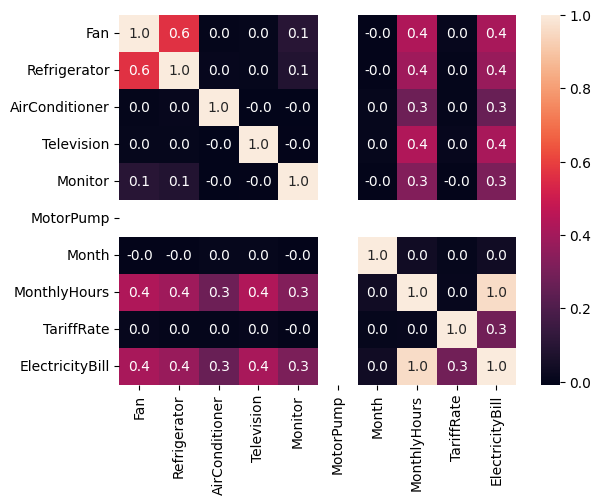

In [ ]:
sns.heatmap(corr,annot=True,fmt='.1f')

In [ ]:
data['Company'].value_counts(ascending=False)


,count
Company,
Ringfeder Power Transmission India Pvt. Ltd.,1486
JSW Energy Ltd.,1477
Guj Ind Power,1476
SJVN Ltd.,1471
"Maha Transco – Maharashtra State Electricity Transmission Co, Ltd.",1470
NTPC Pvt. Ltd.,1466
Optibelt Power Transmission India Private Limited,1463
Kalpataru Power,1456
GE T&D India Limited,1453


In [ ]:
data['MotorPump'].value_counts()




,count
MotorPump,
0,45345


# EDA

Univariate Analysis

In [ ]:
data.columns

Index(['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor',
       'MotorPump', 'Month', 'City', 'Company', 'MonthlyHours', 'TariffRate',
       'ElectricityBill'],
      dtype='object')

In [ ]:
cat=['City', 'Company']
num=['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor',
       'MotorPump', 'Month','MonthlyHours', 'TariffRate']

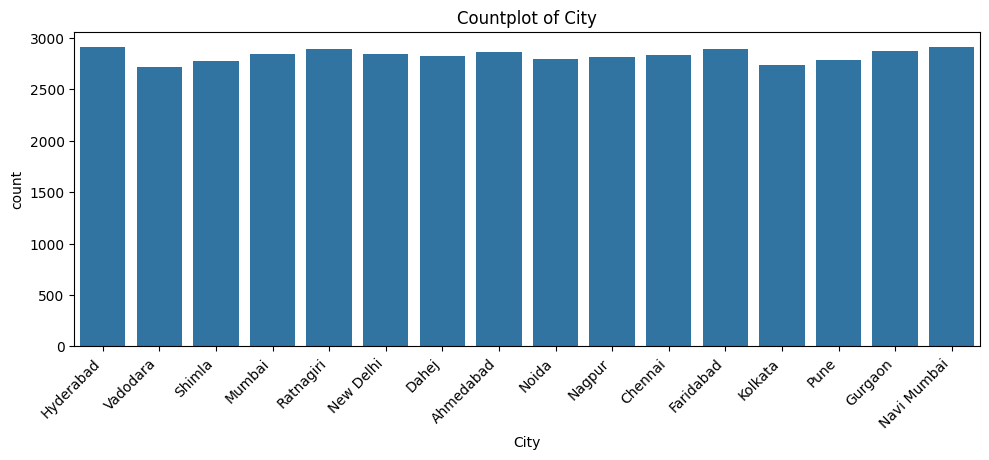

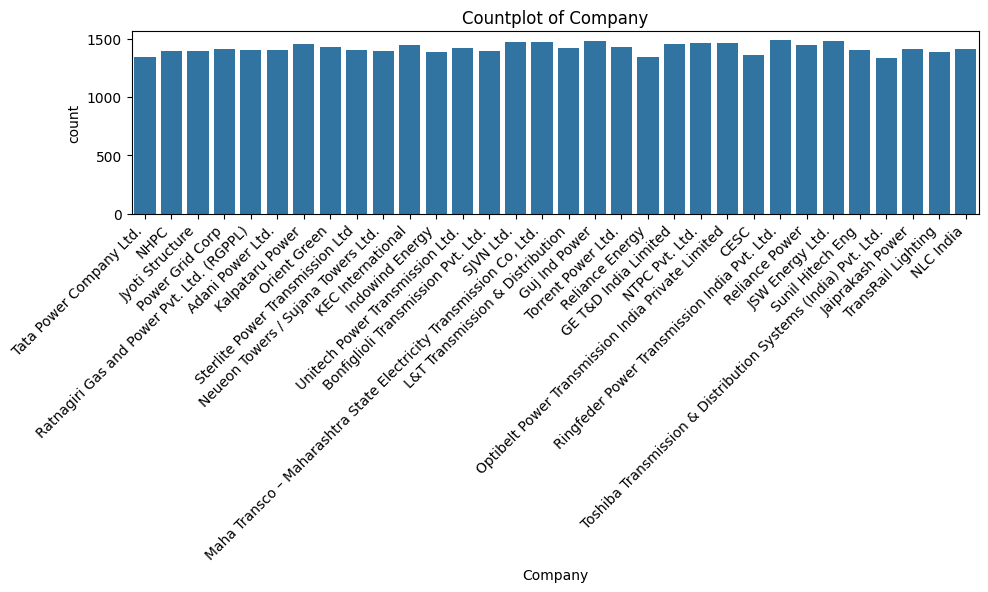

In [ ]:
for index, column_name in enumerate(cat):
   plt.figure(figsize=(10,8))
   plt.subplot(len(cat), 1, index + 1)
   sns.countplot(x=column_name, data=data)
   plt.title(f'Countplot of {column_name}')
   plt.xticks(rotation=45, ha='right')
   plt.tight_layout()
plt.show()

/tmp/ipykernel_2472/1984483521.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[col_name])


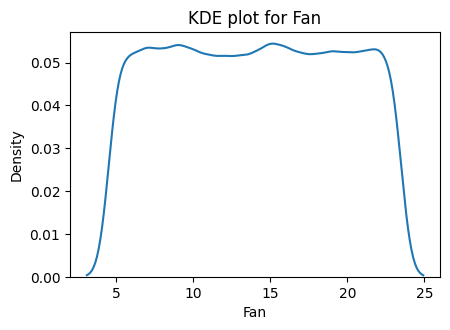

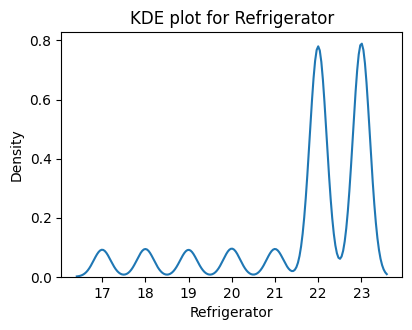

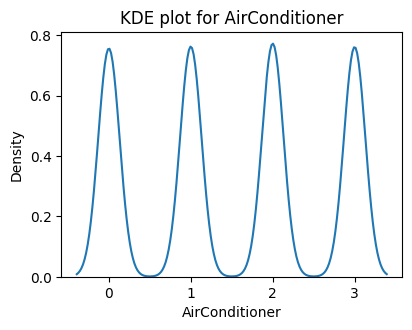

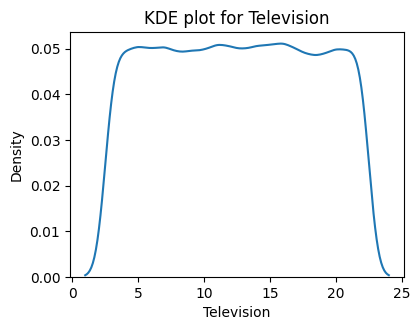

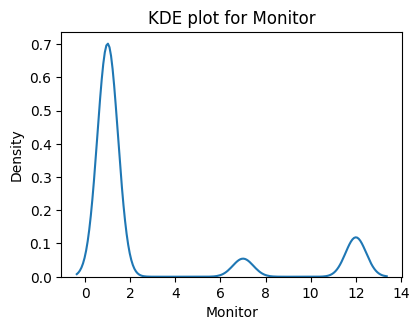

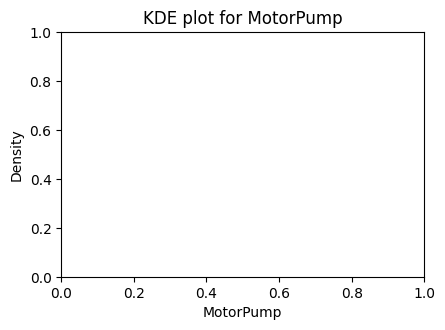

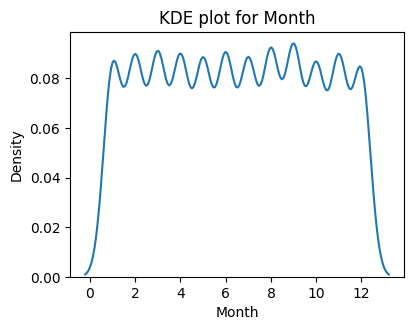

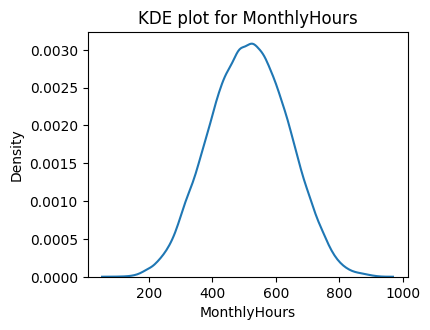

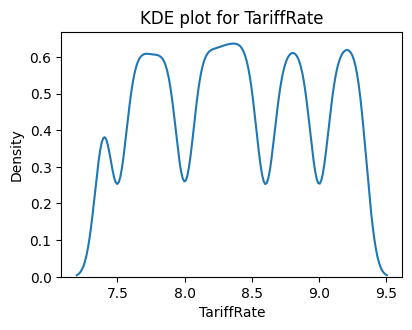

In [ ]:
for index,col_name in enumerate(num):
  plt.figure(figsize=(20,6))
  plt.subplot(2,5,index+1)
  sns.kdeplot(data[col_name])
  plt.title(f'KDE plot for {col_name}')
  plt.xlabel(col_name)
  plt.ylabel('Density')
  plt.tight_layout()
plt.show()

/tmp/ipykernel_2472/2421612880.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[column_name], fill=True)


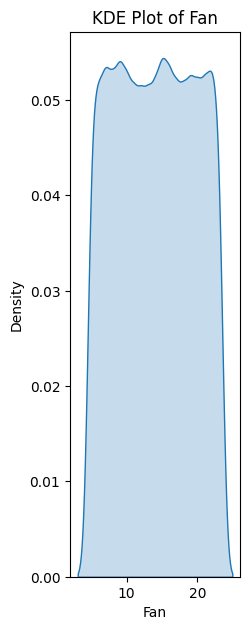

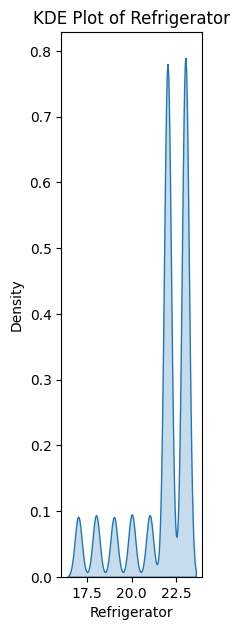

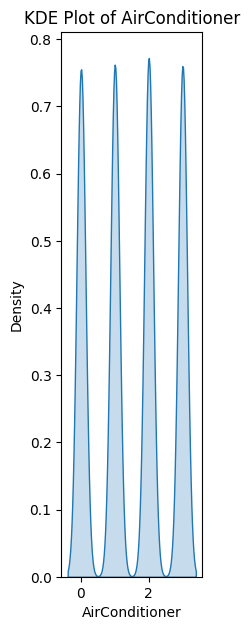

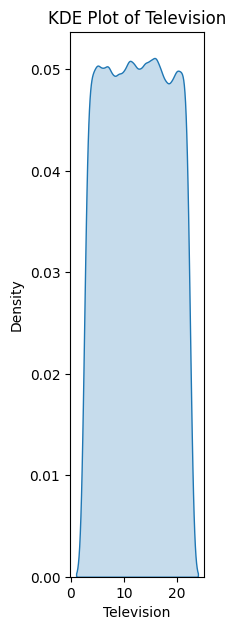

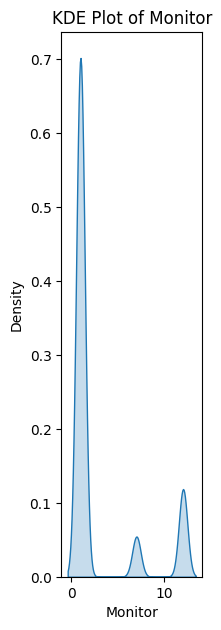

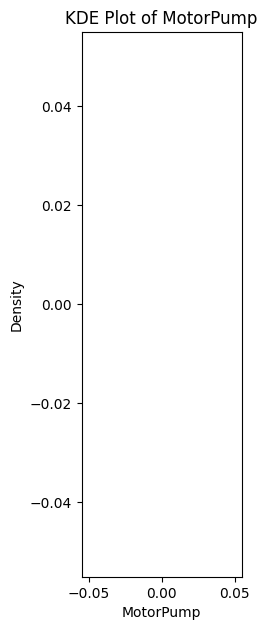

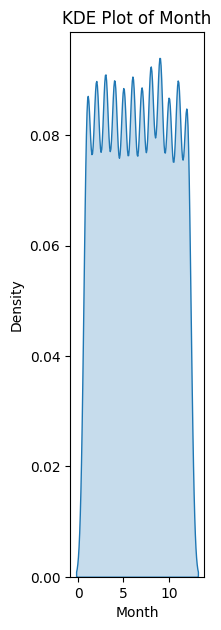

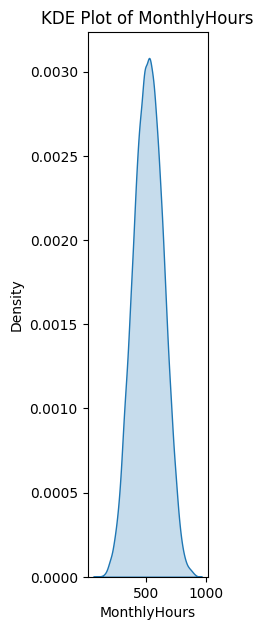

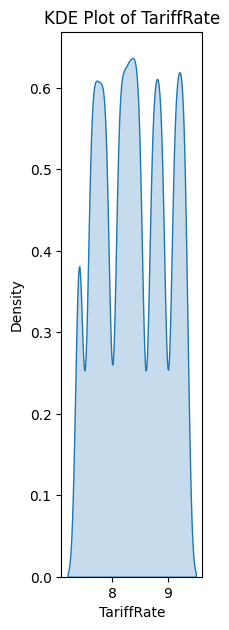

In [ ]:
for plot_index, column_name in enumerate(num):
   plt.figure(figsize=(10,12))
   # Use plot_index (integer) for subplot, and column_name (string) for kdeplot and title
   plt.subplot(2, 5, plot_index + 1)
   sns.kdeplot(data[column_name], fill=True)
   plt.title(f'KDE Plot of {column_name}')
   plt.xlabel(column_name)
   plt.ylabel('Density')
   plt.tight_layout()
plt.show()

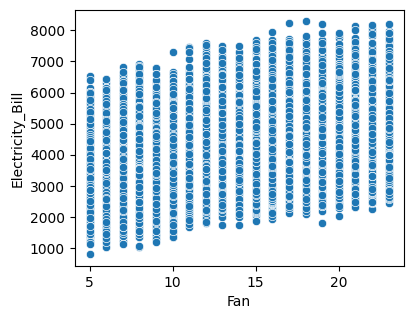

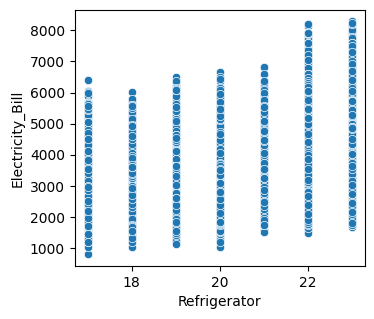

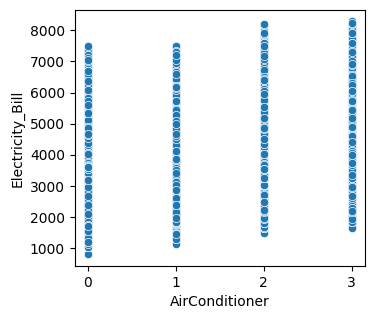

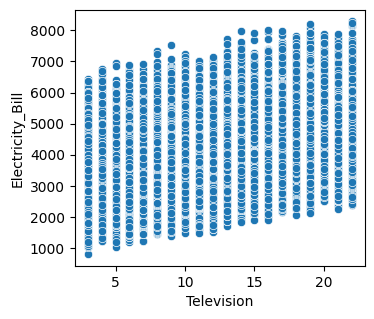

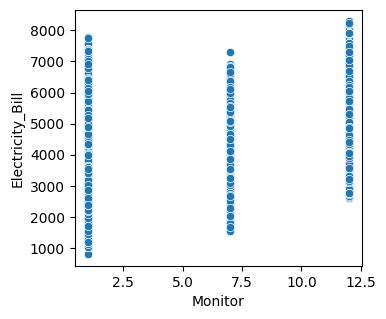

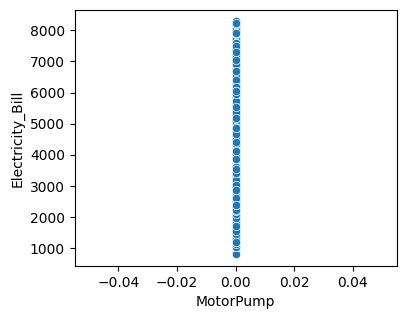

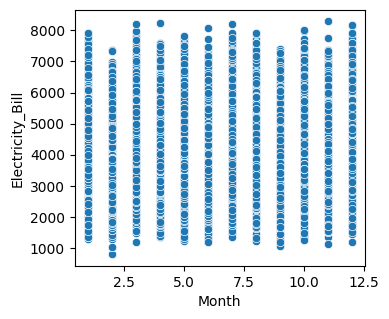

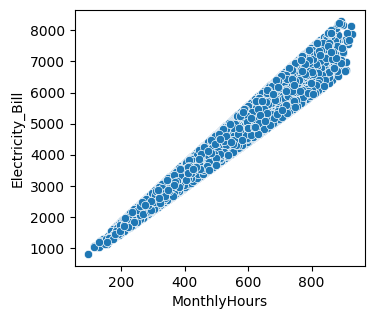

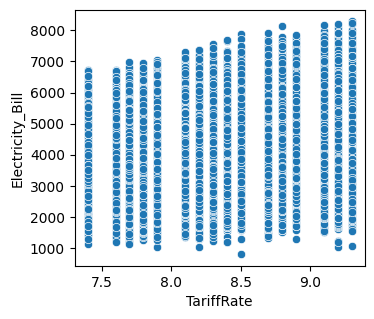

In [ ]:

for index,col in enumerate(num):
  plt.figure(figsize=(18,6))
  plt.subplot(2,5,index+1)
  plt.xlabel(col)
  plt.ylabel('Electricity_Bill')
  sns.scatterplot(x=data[col],y=data['ElectricityBill'])
  plt.tight_layout()
plt.show()

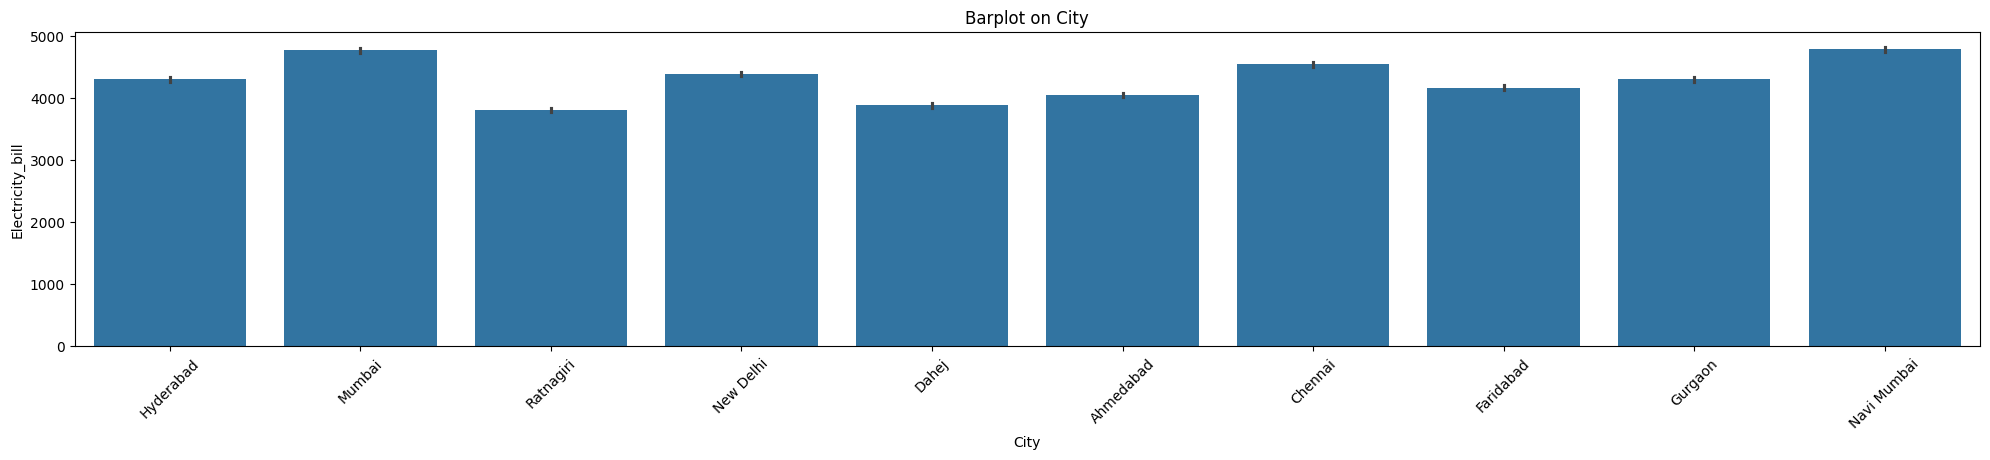

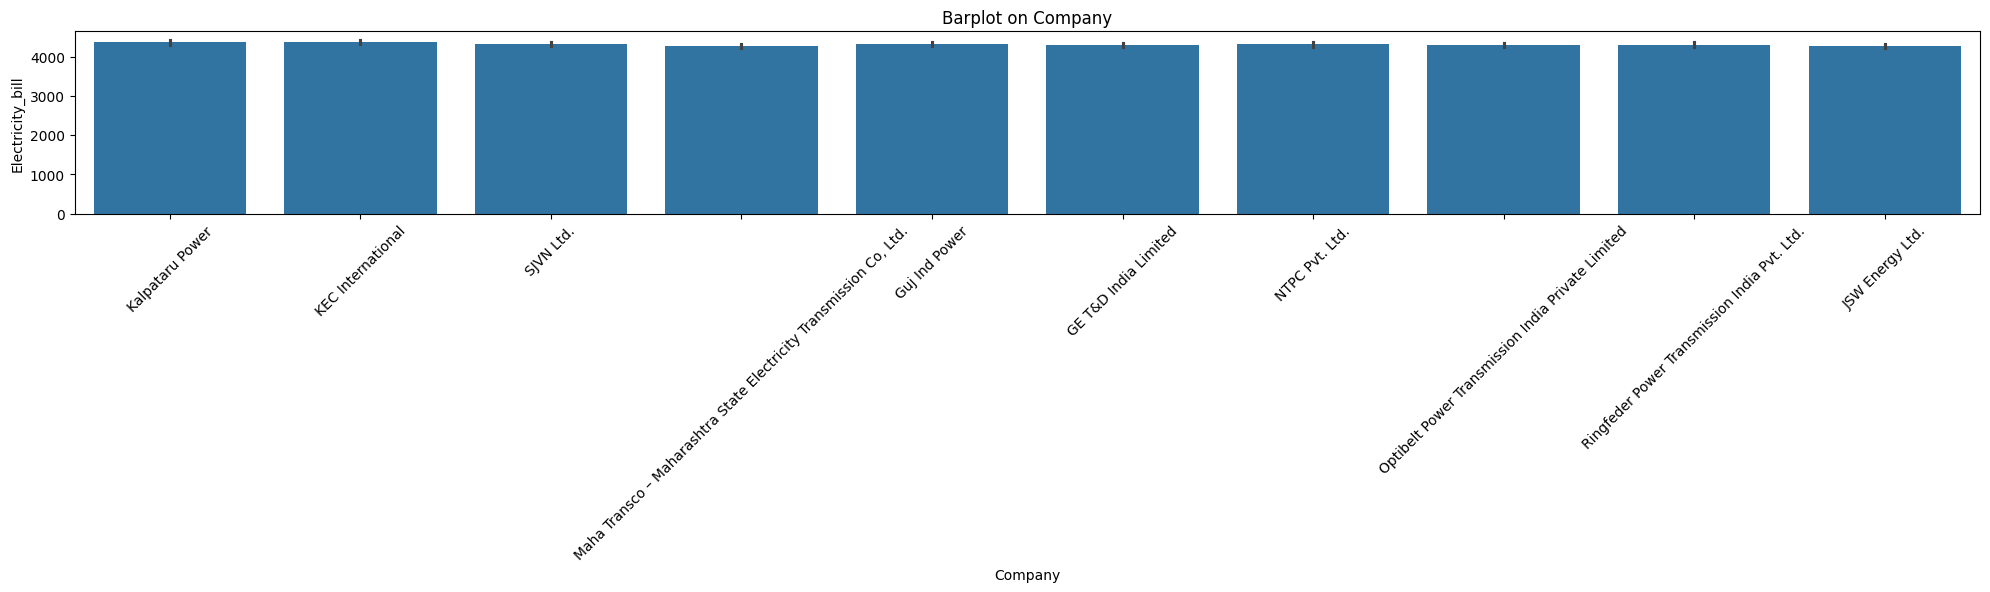

In [ ]:
for index,col in enumerate(cat):
  plt.figure(figsize=(20,8))
  plt.subplot(2,1,index+1)
  top_10=data[col].value_counts(ascending=False).nlargest(10)
  top_data=data[data[col].isin(top_10.index)]
  sns.barplot(x=top_data[col],y=top_data['ElectricityBill'])
  plt.xlabel(col)
  plt.ylabel('Electricity_bill')
  plt.title(f'Barplot on {col}')
  plt.xticks(rotation=45)
  plt.tight_layout()
plt.show()

# Checking Skewness

In [ ]:
data['AirConditioner'].skew()

np.float64(-0.006549174524586746)

In [ ]:
data['Fan'].skew()

np.float64(0.002235942200904085)

In [ ]:
data['Refrigerator'].skew()

np.float64(-1.561661796480539)

In [ ]:
data['Refrigerator']=np.log(data['Refrigerator'])

In [ ]:
data['Television'].skew()

np.float64(0.0014928273987548967)

In [ ]:
data['Monitor'].skew()

np.float64(1.7359194347444684)

In [ ]:
data['Month'].skew()

np.float64(-0.0012013350826281168)

In [ ]:
data['MonthlyHours'].skew()

np.float64(0.006617182398641198)

In [ ]:
data['TariffRate'].skew()

np.float64(0.021142961942007352)

In [ ]:
skewed_col=['Monitor','Refrigerator']

# Visualing Outliers


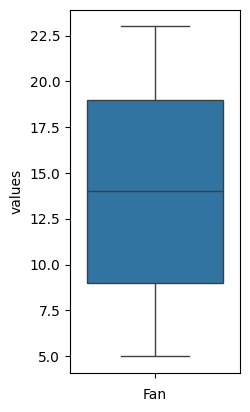

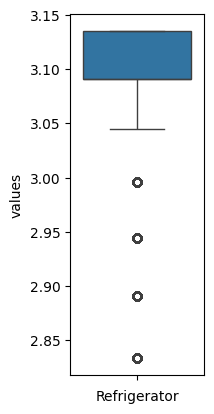

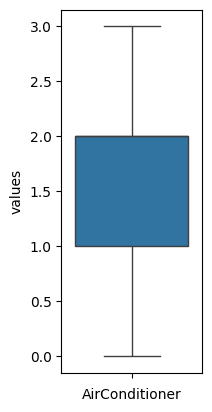

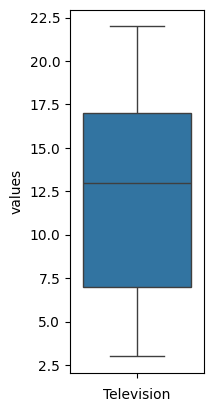

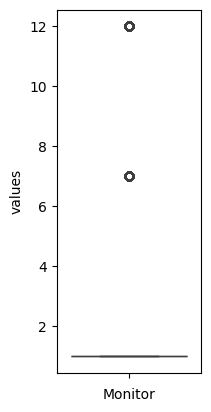

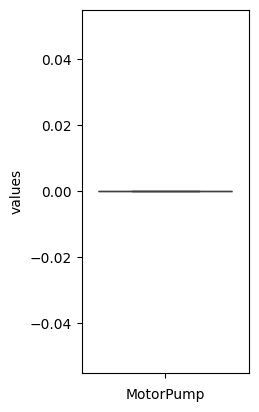

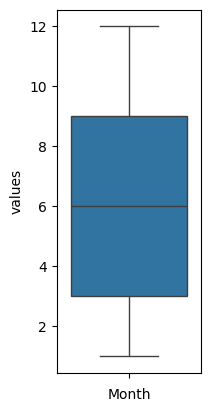

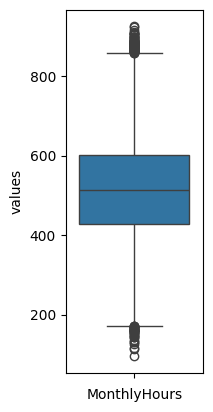

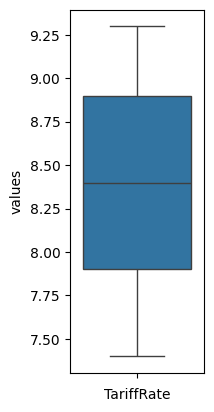

In [ ]:
for index,col in enumerate(num):
  plt.figure(figsize=(10,8))
  plt.subplot(2,5,index+1)
  sns.boxplot(data[col])
  plt.xlabel(col)
  plt.ylabel('values')
  plt.tight_layout()
plt.show()

In [ ]:
Q1=data['MonthlyHours'].quantile(0.25)
Q1

np.float64(429.0)

In [ ]:
Q3=data['MonthlyHours'].quantile(0.75)

In [ ]:
IQR=Q3-Q1
IQR

np.float64(172.0)

In [ ]:
lower=Q1-1.5*IQR
lower

np.float64(171.0)

In [ ]:
upper=Q3+1.5*IQR
upper

np.float64(859.0)

In [ ]:
data['MonthlyHours_capped'] = np.where(
    data['MonthlyHours'] > upper, upper,
    np.where(data['MonthlyHours'] < lower, lower, data['MonthlyHours'])
)

In [ ]:
trf1=ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),['City', 'Company']),
    ('trf',PowerTransformer(method='yeo-johnson'),skewed_col),
    ('standardise',StandardScaler(),num)

],remainder='passthrough')

In [ ]:
pipe=Pipeline([
    ('1',trf1),
    ('lr',LinearRegression())
])

In [ ]:
x=data.drop(columns=['ElectricityBill'])
y=data['ElectricityBill']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
pipe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Company']),
                                                 ('trf', PowerTransformer(),
                                                  ['Monitor', 'Refrigerator']),
                                                 ('standardise',
                                                  StandardScaler(),
                                                  ['Fan', 'Refrigerator',
                                                   'AirConditioner',
                                                   'Television', 'Monitor',
                                                   'MotorPump', 'Month',
                                                   'MonthlyHours',
                                                   'TariffRate'])])),
                ('lr', LinearRegression())])

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
print("Linear_Regression: ",r2_score(y_test,y_pred))

Linear_Regression:  0.9956251945878146


In [ ]:
pipe2=Pipeline([
    ('trf1',trf1),
    ('rf',RandomForestRegressor())
])

In [ ]:
pipe2.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Company']),
                                                 ('trf', PowerTransformer(),
                                                  ['Monitor', 'Refrigerator']),
                                                 ('standardise',
                                                  StandardScaler(),
                                                  ['Fan', 'Refrigerator',
                                                   'AirConditioner',
                                                   'Television', 'Monitor',
                                                   'MotorPump', 'Month',
                                                   'MonthlyHours',
                                                   'TariffRate'])])),
                ('rf', RandomForestRegressor())])

In [ ]:
y_pred2=pipe2.predict(x_test)

In [ ]:
print("Random_Forest: ",r2_score(y_test,y_pred2))

Random_Forest:  0.9999752173008425


In [ ]:
pipe3=Pipeline([
    ('trf1',trf1),
    ('xgb',XGBRegressor())
])

In [ ]:
pipe3.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Company']),
                                                 ('trf', PowerTransformer(),
                                                  ['Monitor', 'Refrigerator']),
                                                 ('standardise',
                                                  StandardScaler(),
                                                  ['Fan', 'Refrigerator',
                                                   'AirConditioner',
                                                   'Television', 'Monitor',
                                                   'MotorPump', 'Month',
                                                   'MonthlyHours',
                                                   'TariffRate'])])),
                ('x...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred3=pipe3.predict(x_test)

In [ ]:
print('XGBoost: ',r2_score(y_test,y_pred3))

XGBoost:  0.9996521711463093


# XG boost is outperforming rest of the models with an r2 score of 0.999


## Feature Importance

Random Forest Feature Importances:


,Feature,Importance
57,standardise__MonthlyHours,0.479210
59,remainder__MonthlyHours_capped,0.441641
58,standardise__TariffRate,0.077912
13,cat__City_Ratnagiri,0.000256
10,cat__City_New Delhi,0.000213
8,cat__City_Nagpur,0.000152
0,cat__City_Ahmedabad,0.000105
2,cat__City_Dahej,0.000069
12,cat__City_Pune,0.000065
6,cat__City_Kolkata,0.000061


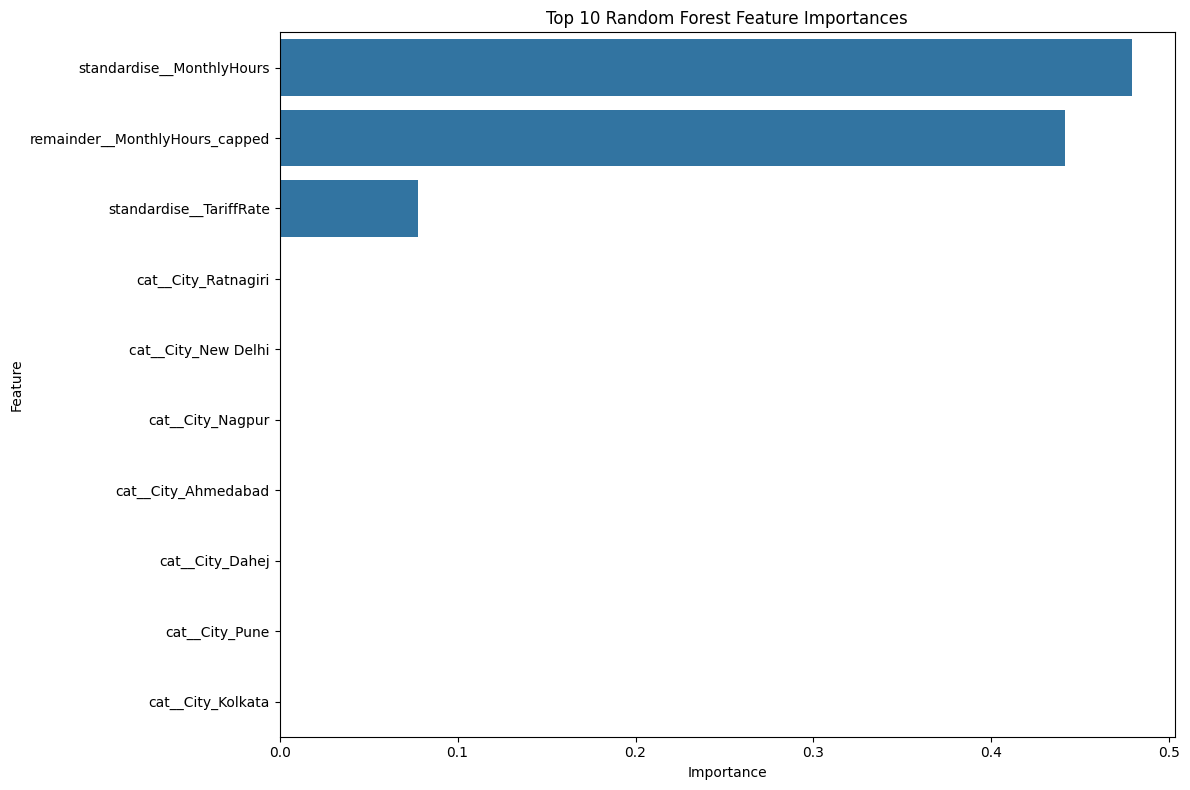

In [159]:
feature_names = trf1.get_feature_names_out()

# Feature importance for RandomForestRegressor
rf_feature_importances = pipe2.named_steps['rf'].feature_importances_
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_feature_importances}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
display(rf_importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(10))
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


XGBoost Feature Importances:


,Feature,Importance
57,standardise__MonthlyHours,0.762108
58,standardise__TariffRate,0.211786
13,cat__City_Ratnagiri,0.012854
9,cat__City_Navi Mumbai,0.003601
32,cat__Company_Neueon Towers / Sujana Towers Ltd.,0.000616
27,cat__Company_L&T Transmission & Distribution,0.000420
34,cat__Company_Orient Green,0.000387
52,standardise__AirConditioner,0.000362
48,trf__Monitor,0.000358
22,cat__Company_JSW Energy Ltd.,0.000347


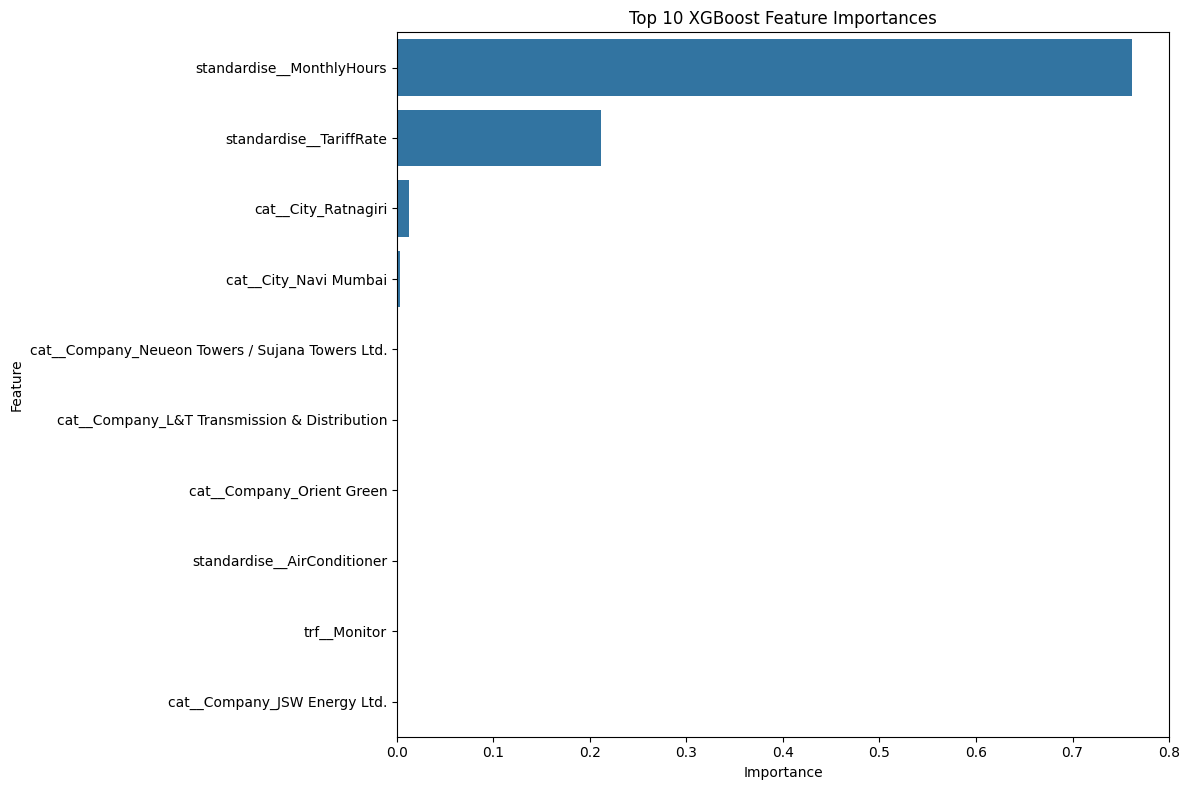

In [160]:
# Feature importance for XGBRegressor
xgb_feature_importances = pipe3.named_steps['xgb'].feature_importances_
xgb_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_feature_importances}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importances:")
display(xgb_importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(10))
plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()